In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# from rpa.style import *

from scipy.integrate import odeint



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def plot_solution(t, t1, solution1, solution2):
    
    # Combine solutions
    solution = np.vstack([solution1, solution2])
    A1, A2, E = solution.T

    # Plot results
    fig, axs = plt.subplots(nrows=3, figsize=(5,4))

    # VEGF plot
    lw = 3
    axs[0].plot(t, A1, label='VEGF', linewidth=lw, color='C0')
    axs[0].set_xlabel('Time')
    axs[0].set_ylabel('VEGF')
    axs[0].set_ylim(bottom=min(A1)*0.75, top=max(A1)*1.25)

    axs[1].plot(t, A2, label='Compensatory\nsignal', linewidth=lw, color='C1')
    axs[1].set_xlabel('Time')
    axs[1].set_ylabel('Compensatory\nFactor')
    axs[1].set_ylim(bottom=min(A2)*0.75, top=max(A2)*1.25)


    axs[2].plot(t, E, label='Endothelial cells', linewidth=lw, color='C2')
    axs[2].set_xlabel('Time')
    axs[2].set_ylabel('Endothelial \ncells')
    axs[2].set_ylim(bottom=0, top=max(E)*1.25)
    axs[2].axhline(y=4, label='Etarget', linestyle='--', color='black')


    for i, ax in enumerate(axs):
        sns.despine(ax=ax)
        ax.set_ylim(bottom=0)
        ax.axvline(x=t1[-1], linestyle='--', color='black')

    plt.tight_layout()





[np.float64(1.2962956756843298), np.float64(0.18518456457322283), np.float64(4.000001368269042)]


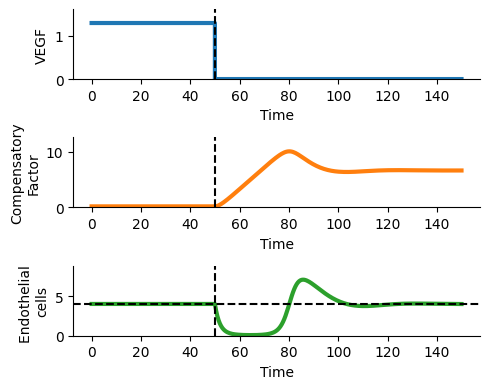

In [6]:
Otarget = 0.9

def compute_oxygen(E, C=0.1, n=1):
    return E**n / (C**n + E**n)


def get_f(
    k1=0.1,
    k2=0.1,
    a1=0.5,
    a2=0.1,
    rE=0.5,
    C=16,
    mu=0.25,
    ):
    def f(x, t):
        A1, A2, E = x
        
        dA1 = k1*(mu*C - E)
        dA2 = k2*(mu*C - E)
        dE = E*( (a1*A1 + a2*A2)*(1-E/(4*mu*C)) - rE) 

        return [dA1, dA2, dE]
    return f

# Initial conditions
# A10 = 0
# A20 = 0 
# E0 = 0.1
# x0 = [A10, A20, E0]
x0 =[np.float64(1.1111111111111074), np.float64(0), np.float64(4.000000000000029)]
x0 =[np.float64(1.2963371181471135), np.float64(0.18522600703600733), np.float64(4.000130671810539)]



# Time points for each phase
duration = 100 # hours
t1 = np.linspace(0, duration/2, 200)
t2 = np.linspace(duration/2, duration*1.5, 200)
t = np.concatenate([t1, t2])

f1 = get_f()
solution1 = odeint(f1, x0, t1)

# Solve second phase with uv=10
x1 = solution1[-1]
f2 = get_f(a1=0)
solution2 = odeint(f2, x1, t2)

solution2[:,0] = 0


print(list(x1))

plot_solution(t, t1, solution1, solution2)


In [ ]:

# Wrong model!
# E doesn't drop after blocking A1, and A2 doesn't compensate

    # E = x

    # O = compute_oxygen(E)
    
    # A1 = k1*(Otarget - O)
    # A2 = k2*(Otarget - O)

    # dE = E*(a1*A1 + a2*A2)

    # return dE